# WCS and Pixel Positions in Data Preview 1
Author: James Robinson

This notebook demonstrates a possible offset in the pixel positions of diaSources when different representations of the World Coordinate System from DP1 are used. These are:
- WCS associated with the Rubin `ExposureF` object - GBDES
- The FITS file format approximation of GBDES

The FITS WCS approximation is expected to not be exact, but good enough for visualisation. It should be accurate to within ~0.05 pixels (https://dp1.lsst.io/products/known_issues_and_subtleties.html#wcs-fits-approximations-and-misleading-interfaces).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lsst.rsp import get_tap_service
from astropy.wcs import WCS
from lsst.afw.image import ExposureF
from lsst.rsp.utils import get_pyvo_auth
from pyvo.dal.adhoc import DatalinkResults
from astropy import visualization as aviz
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import skycoord_to_pixel
from photutils.aperture import CircularAperture
import lsst.geom as geom
from astropy import units as u

In [2]:
service_tap = get_tap_service("tap")
assert service_tap is not None

# Query a visit image

In [3]:
# visit =  2024112600130
# visit = 2024112700161
# visit = 2024120300164	
# visit = 2024120300156
visit = 2024112700171

detector = 0
calib_level = [2,3] # query both the visit and the diff image
calib_plot = 2 # plot the visit image
# calib_plot = 3 # plot the diff image

In [4]:
query = """SELECT access_url, calib_level FROM ivoa.ObsCore
WHERE lsst_visit = {} AND lsst_detector = {} AND calib_level IN {}
""".format(
    visit, detector, tuple(calib_level)
)
print(query)

job = service_tap.submit_job(query)
job.run()
job.wait(phases=["COMPLETED", "ERROR"])
print("Job phase is", job.phase)
if job.phase == "ERROR":
    job.raise_if_error()
assert job.phase == "COMPLETED"
results = job.fetch_result().to_table()
print(results, len(results))
assert len(results) == len(calib_level)

df_visit = results.to_pandas()
df_visit

SELECT access_url, calib_level FROM ivoa.ObsCore
WHERE lsst_visit = 2024112700171 AND lsst_detector = 0 AND calib_level IN (2, 3)

Job phase is COMPLETED
                                                                access_url                                                                 ...
------------------------------------------------------------------------------------------------------------------------------------------ ...
https://data.lsst.cloud/api/datalink/links?ID=ivo%3A%2F%2Forg.rubinobs%2Flsst-dp1%3Frepo%3Ddp1%26id%3Db540c29d-ad18-49f2-91df-216759e798d3 ...
https://data.lsst.cloud/api/datalink/links?ID=ivo%3A%2F%2Forg.rubinobs%2Flsst-dp1%3Frepo%3Ddp1%26id%3Da603eb62-be42-4fcd-802c-9aa1ae2e0d63 ... 2


,access_url,calib_level
0,https://data.lsst.cloud/api/datalink/links?ID=...,2
1,https://data.lsst.cloud/api/datalink/links?ID=...,3


In [5]:
# get the image as an ExposureF object
datalink_url = df_visit[df_visit["calib_level"]==calib_plot].iloc[0]["access_url"]
dl_result = DatalinkResults.from_result_url(datalink_url, session=get_pyvo_auth())
image_url = dl_result.getrecord(0).get('access_url')
exp = ExposureF(image_url)

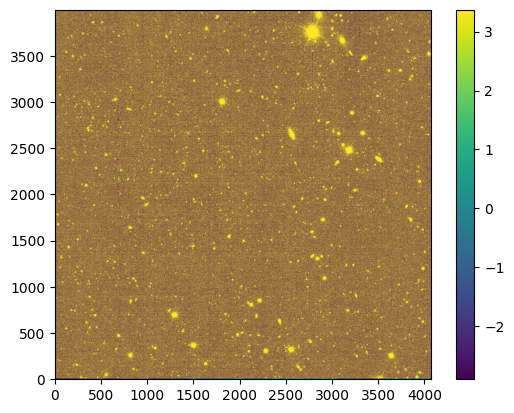

In [6]:
# plot the image in pixel coords
img = exp.image.getArray() 

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0, 0])

# Plot the image with norm and scaling
norm = aviz.ImageNormalize(img, interval=aviz.ZScaleInterval())
s1 = ax1.imshow(img, norm=norm, origin="lower")
cbar = plt.colorbar(s1)

plt.show()

# Query all diaSources in visit detector

In [7]:
query = """SELECT diaSourceId, ssObjectId, visit, detector, band, ra, dec, raErr, decErr, coord_ra, coord_dec, x, y, xErr, yErr
        FROM dp1.DiaSource
        WHERE visit={} AND detector={}
        """.format(visit,detector)

print(query)
job = service_tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'

results = job.fetch_result().to_table()
df = results.to_pandas()
df

SELECT diaSourceId, ssObjectId, visit, detector, band, ra, dec, raErr, decErr, coord_ra, coord_dec, x, y, xErr, yErr
        FROM dp1.DiaSource
        WHERE visit=2024112700171 AND detector=0
        
Job phase is COMPLETED


,diaSourceId,ssObjectId,visit,detector,band,ra,dec,raErr,decErr,coord_ra,coord_dec,x,y,xErr,yErr
0,600403740461105207,0,2024112700171,0,i,53.222907,-27.808214,0.000015,0.000019,53.222759,-27.808278,1379.403703,512.204982,0.363680,0.281760
1,600403740461105167,0,2024112700171,0,i,53.182601,-27.768271,NaN,NaN,53.182605,-27.768278,433.760836,689.152248,NaN,NaN
2,600403740461105168,0,2024112700171,0,i,53.231302,-27.851856,NaN,NaN,53.231301,-27.851858,2119.116372,803.980491,NaN,NaN
3,600403740461105169,0,2024112700171,0,i,53.229120,-27.850937,NaN,NaN,53.229117,-27.850938,2087.008479,825.088917,NaN,NaN
4,600403740461105171,0,2024112700171,0,i,53.216517,-27.836186,0.000066,0.000069,53.216517,-27.836186,1756.508514,859.194360,1.186430,1.382370
5,600403740461105172,0,2024112700171,0,i,53.217176,-27.852750,0.000025,0.000029,53.217281,-27.852684,2016.483421,1004.296031,0.529960,0.496307
6,600403740461105175,0,2024112700171,0,i,53.137420,-27.780128,0.000025,0.000020,53.137420,-27.780128,243.813882,1413.968093,0.234295,0.587664
7,600403740461105176,0,2024112700171,0,i,53.185698,-27.850620,0.000048,0.000041,53.185713,-27.850352,1724.489364,1412.432919,0.548231,1.097140
8,600403740461105178,0,2024112700171,0,i,53.180706,-27.851762,0.000098,0.000075,53.180706,-27.851762,1700.947644,1490.926372,0.772787,2.272820
9,600403740461105184,0,2024112700171,0,i,53.093082,-27.823868,NaN,NaN,53.093084,-27.823867,551.207474,2423.571079,NaN,NaN


In [14]:
# calculate the pixel positions of each source using the different WCSes
wcs_exp = exp.wcs # ExposureF WCS
wcs_fits = WCS(exp.getWcs().getFitsMetadata()) # ExposureF WCS converted to fits WCS - see https://community.lsst.org/t/visualizing-images-in-sky-coordinates-using-wcs-in-a-notebook/4210/8

df[["x_exp","y_exp","x_fits","y_fits"]] = np.nan
for i in range(len(df)):
    # convert source coordinates to Rubin WCS pixel position
    # coord = geom.SpherePoint(df.iloc[i]["coord_ra"] * geom.degrees, df.iloc[i]["coord_dec"] * geom.degrees)
    coord = geom.SpherePoint(df.iloc[i]["ra"] * geom.degrees, df.iloc[i]["dec"] * geom.degrees)
    pos_exp = wcs_exp.skyToPixel(coord)  # pos.x, pos.y
    df.loc[i,"x_exp"] = pos_exp.x
    df.loc[i,"y_exp"] = pos_exp.y
    
    # convert target coords using the INEXACT fits approximation WCS
    # c = SkyCoord(df.iloc[i]["coord_ra"], df.iloc[i]["coord_dec"], unit=(u.deg, u.deg))
    c = SkyCoord(df.iloc[i]["ra"], df.iloc[i]["dec"], unit=(u.deg, u.deg))
    pos_fits = skycoord_to_pixel(c, wcs_fits)
    df.loc[i,"x_fits"] = pos_fits[0]
    df.loc[i,"y_fits"] = pos_fits[1]

In [15]:
# %matplotlib widget 

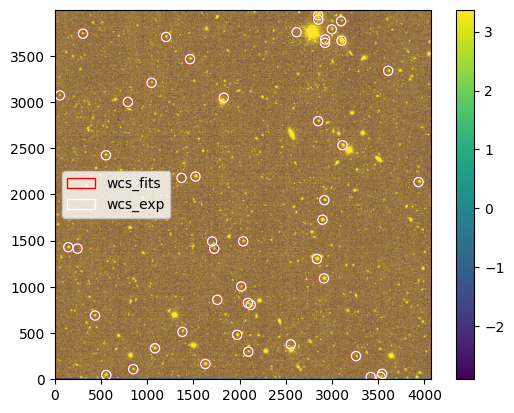

In [16]:
# plot the image with the source positions for both WCSes
img = exp.image.getArray()
wcs = WCS(exp.getWcs().getFitsMetadata()) # ExposureF WCS converted to fits WCS

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0, 0])

# Plot the image with norm and scaling
norm = aviz.ImageNormalize(img, interval=aviz.ZScaleInterval())
s1 = ax1.imshow(img, norm=norm, origin="lower")
cbar = plt.colorbar(s1)

for i in range(len(df)):

    aperture = CircularAperture(
        positions=np.array([df.iloc[i]["x_fits"],df.iloc[i]["y_fits"]]),
        r=50,
    )
    aperture.plot(color="r", label = "wcs_fits")
    
    aperture = CircularAperture(
        positions=np.array([df.iloc[i]["x_exp"],df.iloc[i]["y_exp"]]),
        r=50,
    )
    aperture.plot(color="w", label = "wcs_exp")

    if i==0:
        ax1.legend()

plt.show()

# Find pixel position offsets for the diaSources

In [17]:
# calculate the position offset between the different WCSes
df["delta_pos_fits"] = np.sqrt(((df["x_exp"] - df["x_fits"])**2.0) + ((df["y_exp"] - df["y_fits"])**2.0)) # compare the ExposureF and FITS WCS positions
df["delta_pos_exp"] = np.sqrt(((df["x_exp"] - df["x"])**2.0) + ((df["y_exp"] - df["y"])**2.0)) # compare calculated ExposureF position with diaSource catalogue position

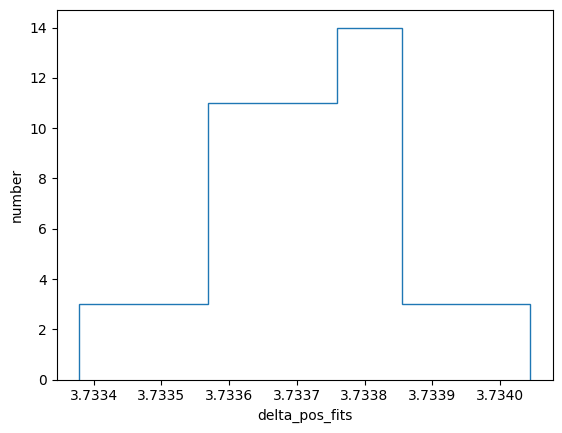

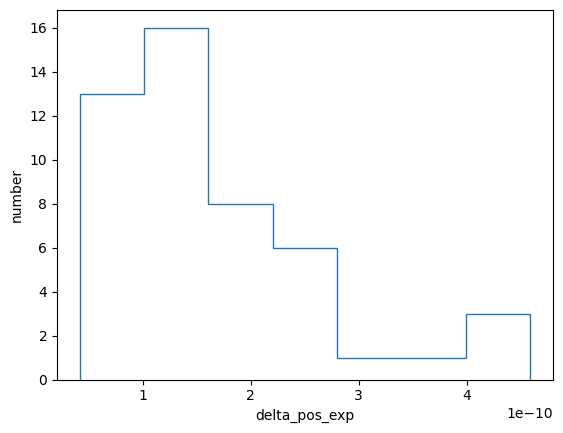

In [18]:
# Distribution of position offsets
df_plot = df

for x_plot in ["delta_pos_fits","delta_pos_exp"]:
    fig = plt.figure()
    gs = gridspec.GridSpec(1, 1)
    ax1 = plt.subplot(gs[0, 0])
    
    ax1.hist(df_plot[x_plot],bins = "auto", histtype = "step")
    
    ax1.set_xlabel(x_plot)
    ax1.set_ylabel("number")
    
    plt.show()

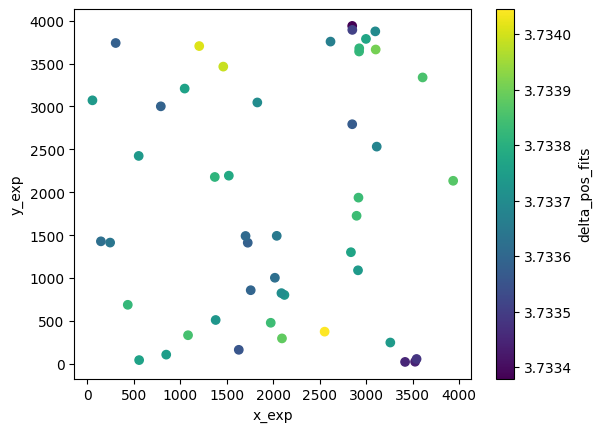

In [19]:
# Plot to check if offset is a function of detector position
x_plot = "x_exp"
y_plot = "y_exp"
c_plot = "delta_pos_fits"
df_plot = df

fig = plt.figure()
gs = gridspec.GridSpec(1, 1)
ax1 = plt.subplot(gs[0, 0])

s1 = ax1.scatter(df_plot[x_plot],df_plot[y_plot],c=df_plot[c_plot],)
cbar1 = plt.colorbar(s1)

ax1.set_xlabel(x_plot)
ax1.set_ylabel(y_plot)
cbar1.set_label(c_plot)

plt.show()